# **Crypto Market Exploration**
---
### What do we actually want to understand?

- *What does BTC trade data look like?*
- *What is the mid-price doing over time?*
- *How wide is the spread?*
- *When is the market most active?*
- *Are there anomolies or weird patterns?*

## 1) Get BTC Data
---

### Load Libraries

In [81]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


Get Bitcoin trade data from Coinbase.

In [82]:
def get_btc_trades(limit=1000):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    params = {"limit": limit}
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data)
    return df

trades = get_btc_trades()
print(f"Got {len(trades)} trades")


Got 1000 trades


In [83]:
trades.head()

,trade_id,side,size,price,time
0,1017368247,sell,0.00030549,81016.41000000,2026-05-13T02:13:20.316959Z
1,1017368246,sell,0.00018651,81016.41000000,2026-05-13T02:13:20.213471Z
2,1017368245,sell,0.00299869,81016.41000000,2026-05-13T02:13:19.685991Z
3,1017368244,sell,0.00037184,81016.41000000,2026-05-13T02:13:19.599813Z
4,1017368243,sell,0.00001222,81016.41000000,2026-05-13T02:13:18.936212Z


In [84]:
trades['price'] = pd.to_numeric(trades['price'])
trades['size'] = pd.to_numeric(trades['size'])
trades['time'] = pd.to_datetime(trades['time'])

trades = trades.sort_values('time').reset_index(drop=True)
trades = trades.set_index("time")


print(trades.dtypes)
trades.head()

trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-13 02:07:13.987441+00:00,1017367248,sell,0.000300,81014.44
2026-05-13 02:07:14.751266+00:00,1017367249,sell,0.000197,81014.44
2026-05-13 02:07:14.752706+00:00,1017367250,sell,0.000244,81014.44
2026-05-13 02:07:15.163977+00:00,1017367251,sell,0.000489,81014.44
2026-05-13 02:07:15.644653+00:00,1017367252,sell,0.001200,81014.44


## 2) Calculate mid-price over time
---

### Noise vs. lag tradeoff (will adjust this parameter later)

In [85]:
window = 10
trades['mid_price'] = trades['price'].rolling(window=window).mean()
# trades = trades.sort_index(ascending=False)
trades.tail(window + 5)

,trade_id,side,size,price,mid_price
time,,,,,
2026-05-13 02:13:09.903295+00:00,1017368233,buy,4.000000e-08,81016.41,81016.482
2026-05-13 02:13:11.345261+00:00,1017368237,sell,7.625800e-04,81016.41,81016.482
2026-05-13 02:13:11.345261+00:00,1017368235,sell,5.110800e-04,81016.41,81016.482
2026-05-13 02:13:11.345261+00:00,1017368234,sell,2.555300e-04,81016.41,81016.482
2026-05-13 02:13:11.345261+00:00,1017368236,sell,1.277680e-03,81016.41,81016.483
2026-05-13 02:13:11.542600+00:00,1017368238,sell,3.996000e-05,81016.41,81016.484
2026-05-13 02:13:12.139107+00:00,1017368239,sell,6.953000e-05,81016.41,81016.485
2026-05-13 02:13:12.519987+00:00,1017368240,sell,1.287610e-03,81016.41,81016.486
2026-05-13 02:13:13.499729+00:00,1017368241,sell,3.607500e-04,81016.41,81016.486


In [86]:
trades['side_switch'] = trades['side'] != trades['side'].shift(1)
switches = trades[trades['side_switch']]

In [87]:
trades['price_diff'] = switches['price'].diff().abs()
trades['spread_estimate'] = trades['price_diff'].rolling(window=window).mean()
trades.tail(window + 5)

,trade_id,side,size,price,mid_price,side_switch,price_diff,spread_estimate
time,,,,,,,,
2026-05-13 02:13:09.903295+00:00,1017368233,buy,4.000000e-08,81016.41,81016.482,True,0.0,NaN
2026-05-13 02:13:11.345261+00:00,1017368237,sell,7.625800e-04,81016.41,81016.482,True,0.0,NaN
2026-05-13 02:13:11.345261+00:00,1017368235,sell,5.110800e-04,81016.41,81016.482,False,0.0,NaN
2026-05-13 02:13:11.345261+00:00,1017368234,sell,2.555300e-04,81016.41,81016.482,False,0.0,0.006
2026-05-13 02:13:11.345261+00:00,1017368236,sell,1.277680e-03,81016.41,81016.483,False,0.0,0.005
2026-05-13 02:13:11.542600+00:00,1017368238,sell,3.996000e-05,81016.41,81016.484,False,NaN,NaN
2026-05-13 02:13:12.139107+00:00,1017368239,sell,6.953000e-05,81016.41,81016.485,False,NaN,NaN
2026-05-13 02:13:12.519987+00:00,1017368240,sell,1.287610e-03,81016.41,81016.486,False,NaN,NaN
2026-05-13 02:13:13.499729+00:00,1017368241,sell,3.607500e-04,81016.41,81016.486,False,NaN,NaN


In [88]:
switches = trades[trades['side_switch']]
switches.tail()

,trade_id,side,size,price,mid_price,side_switch,price_diff,spread_estimate
time,,,,,,,,
2026-05-13 02:13:08.168323+00:00,1017368224,sell,6.940000e-06,81016.41,81023.545,True,6.29,NaN
2026-05-13 02:13:09.179769+00:00,1017368227,buy,1.400000e-05,81016.40,81020.532,True,0.01,NaN
2026-05-13 02:13:09.271209+00:00,1017368231,sell,3.085900e-04,81016.41,81017.459,True,0.01,NaN
2026-05-13 02:13:09.903295+00:00,1017368233,buy,4.000000e-08,81016.41,81016.482,True,0.00,NaN
2026-05-13 02:13:11.345261+00:00,1017368237,sell,7.625800e-04,81016.41,81016.482,True,0.00,NaN


In [89]:
print(f"Average estimated spread: ${switches['price_diff'].mean():.2f}")
print(f"Median estimated spread: ${switches['price_diff'].mean():.2f}")
print(f"Min: ${switches['price_diff'].min():.2f}")
print(f"Max: ${switches['price_diff'].max():.2f}")

Average estimated spread: $1.31
Median estimated spread: $1.31
Min: $0.00
Max: $20.08


- **$1.72 average spread** on a BTC price of roughly $60,000 means the spread is about 0.003% of the price. That's extremely tight — which tells you BTC is a very liquid, heavily competed market. Lots of market makers fighting for the same edge.

- **$0.01 minimum** — that's essentially zero. Those are trades happening at nearly identical prices, back to back. High activity, lots of competition.

- **$18.55 maximum** — that's a spread blowout. Something caused liquidity to temporarily disappear. Could be a news event, a large order wiping out the book, or just a thin moment. This is exactly the kind of environment where a naive market maker gets hurt badly.

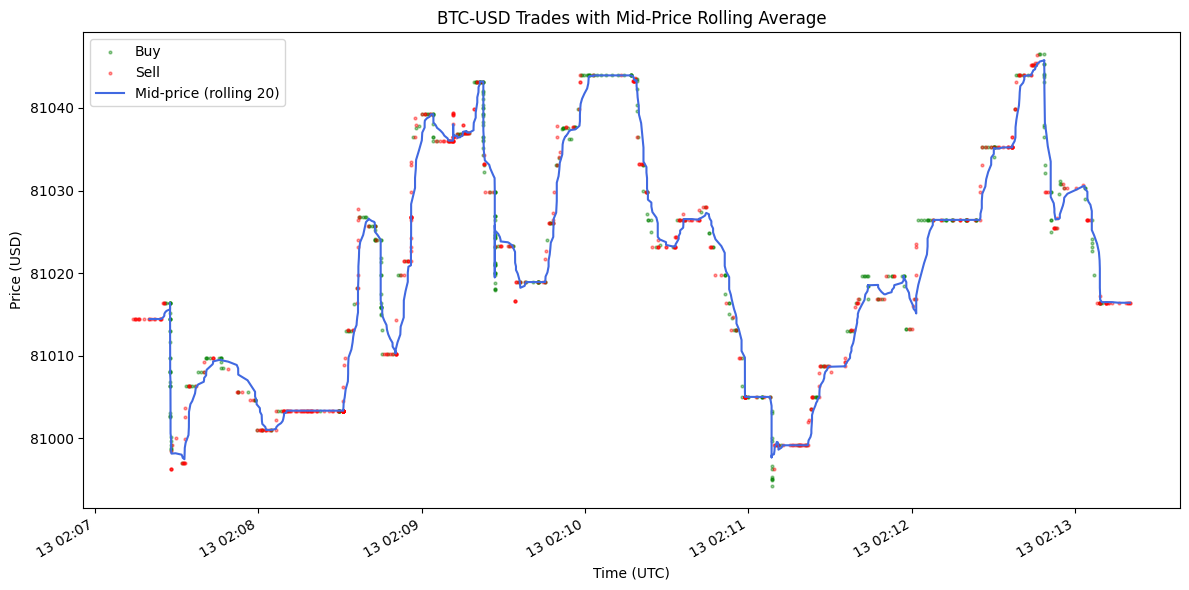

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))

buys = trades[trades['side'] == 'buy']
sells = trades[trades['side'] == 'sell']

ax.scatter(buys.index, buys['price'], color='green', s=4, alpha=0.4, label='Buy')
ax.scatter(sells.index, sells['price'], color='red', s=4, alpha=0.4, label='Sell')

ax.plot(trades.index, trades['mid_price'], color='royalblue', linewidth=1.5, label='Mid-price (rolling 20)')

ax.set_title('BTC-USD Trades with Mid-Price Rolling Average')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Price (USD)')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary
---
## What I learned:
- **Mid-price:** a great estimator to track the market, so I can sit in the middle of the highest bid and ask. Used a rolling average of prices to estimate it.

- **Noise vs. Lag Tradeoff:** if the window is too big the mid-price lags but it's smoother. If the window is too small, the mid-price is noisy but reactive. Short window for order book estimation. Longer book for trade strategy implentation

- **Average Spread:** Average bid-ask spread around the mid-price.